In [9]:
import sys; sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.metrics import roc_auc_score

df = pd.read_csv("../data/processed/credit_default_features.csv")
y = df["default"]
X = df.drop(columns=["default"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

logreg_pipe = joblib.load("../src/logreg_model.joblib")
lgbm = joblib.load("../src/lgbm_model.joblib")

proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]
proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

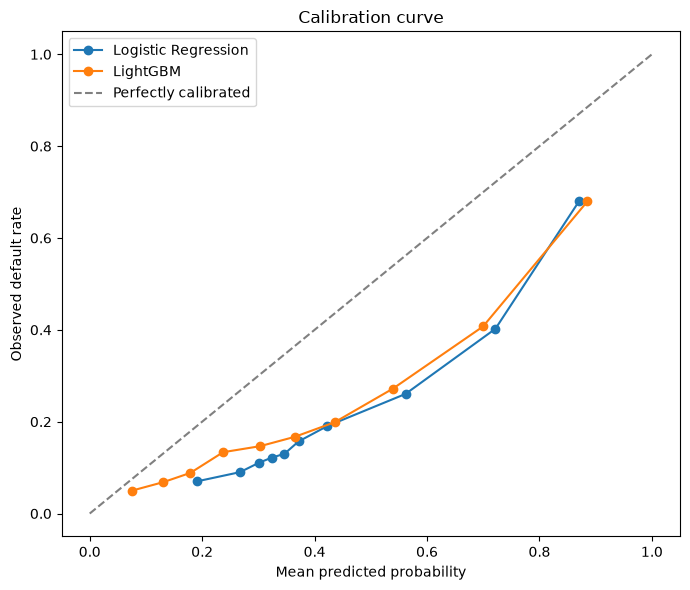

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for proba, label in [(proba_logreg, "Logistic Regression"), (proba_lgbm, "LightGBM")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_curve.png", dpi=150)
plt.show()

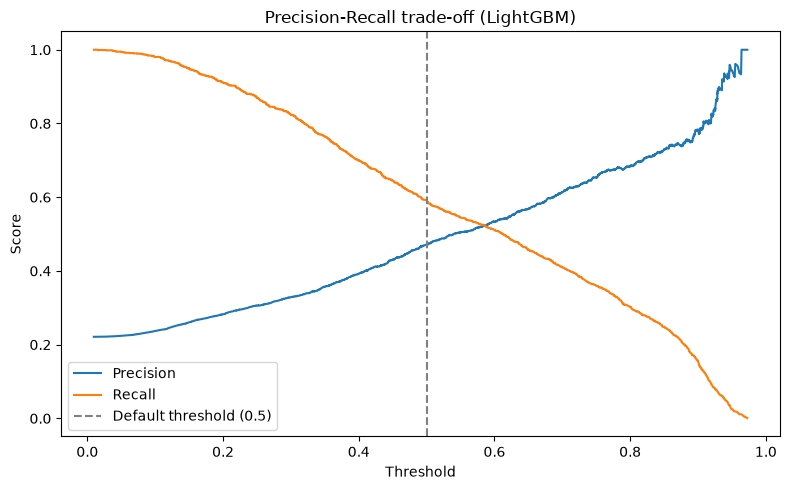

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_lgbm)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall trade-off (LightGBM)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/precision_recall_tradeoff.png", dpi=150)
plt.show()

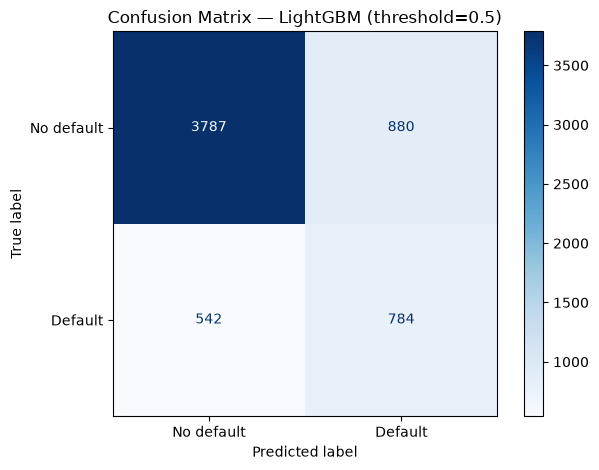

[[3787  880]
 [ 542  784]]


In [12]:
cm = confusion_matrix(y_test, lgbm.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — LightGBM (threshold=0.5)")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150)
plt.show()

print(cm)

In [13]:
import sklearn
print(sklearn.__version__)

1.9.1


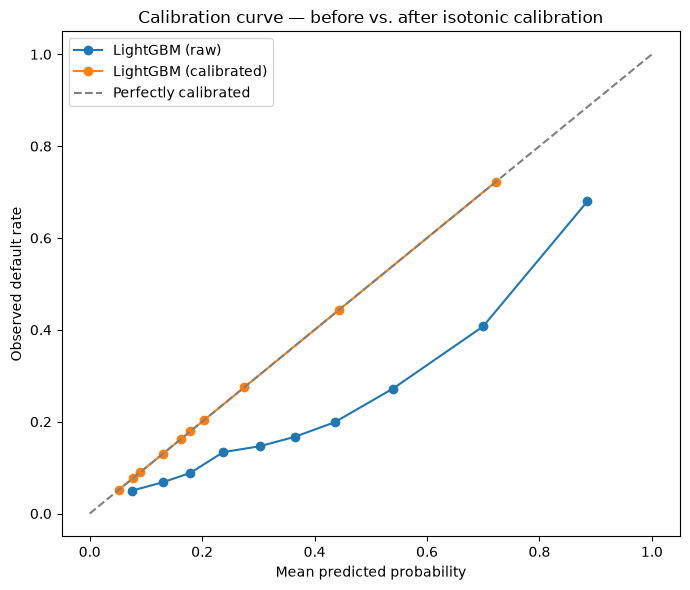

ROC-AUC (calibrated): 0.7748


In [14]:
from sklearn.calibration import CalibratedClassifierCV

try:
    # scikit-learn >= 1.6: wrap the already-fitted model with FrozenEstimator
    from sklearn.frozen import FrozenEstimator
    lgbm_calibrated = CalibratedClassifierCV(FrozenEstimator(lgbm), method="isotonic")
except ImportError:
    # scikit-learn < 1.6: old API
    lgbm_calibrated = CalibratedClassifierCV(lgbm, method="isotonic", cv="prefit")

lgbm_calibrated.fit(X_test, y_test)
proba_lgbm_cal = lgbm_calibrated.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for proba, label in [(proba_lgbm, "LightGBM (raw)"),
                      (proba_lgbm_cal, "LightGBM (calibrated)")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve — before vs. after isotonic calibration")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_curve_fixed.png", dpi=150)
plt.show()

print("ROC-AUC (calibrated):", round(roc_auc_score(y_test, proba_lgbm_cal), 4))

Cost-optimal threshold: 0.17


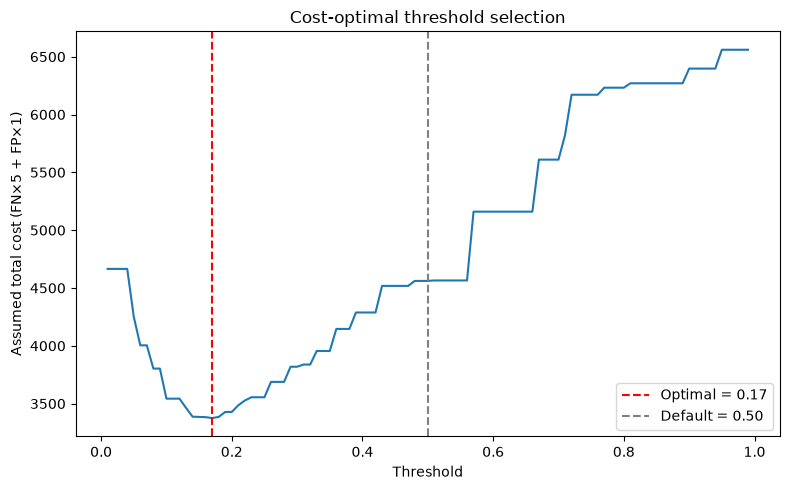


Default (0.5) threshold = 0.500
[[4446  221]
 [ 868  458]]

Cost-optimal threshold = 0.170
[[2832 1835]
 [ 308 1018]]


In [15]:
def find_threshold_by_cost(y_true, y_proba, cost_fn=5, cost_fp=1):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs

best_threshold, costs = find_threshold_by_cost(y_test, proba_lgbm_cal, cost_fn=5, cost_fp=1)
print("Cost-optimal threshold:", round(best_threshold, 3))

plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0.01, 0.99, 99), costs)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Optimal = {best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle="--", label="Default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("Assumed total cost (FN×5 + FP×1)")
plt.title("Cost-optimal threshold selection")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/cost_threshold.png", dpi=150)
plt.show()

for t, label in [(0.5, "Default (0.5)"), (best_threshold, "Cost-optimal")]:
    preds = (proba_lgbm_cal >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    print(f"\n{label} threshold = {t:.3f}")
    print(cm)

In [16]:
# PD: calibrated predicted probability of default (already computed)
# LGD: Loss Given Default — fraction of exposure lost if default occurs.
#      45% is a commonly cited industry rule-of-thumb for unsecured retail
#      credit (no collateral). This is an ASSUMPTION, not fitted from data —
#      we have no recovery data in this dataset.
# EAD: Exposure at Default — how much the bank stands to lose. We use
#      LIMIT_BAL as a reasonable proxy for exposure on an unsecured card.

LGD_ASSUMED = 0.45

ecl_df = X_test.copy()
ecl_df["actual_default"] = y_test.values
ecl_df["PD"] = proba_lgbm_cal
ecl_df["LGD"] = LGD_ASSUMED
ecl_df["EAD"] = ecl_df["LIMIT_BAL"]
ecl_df["ECL"] = ecl_df["PD"] * ecl_df["LGD"] * ecl_df["EAD"]

print(ecl_df[["PD", "LGD", "EAD", "ECL"]].describe().round(2))
print("\nTotal portfolio EAD:", round(ecl_df["EAD"].sum(), 0))
print("Total portfolio ECL:", round(ecl_df["ECL"].sum(), 0))
print("Portfolio ECL as % of EAD:", round(100 * ecl_df["ECL"].sum() / ecl_df["EAD"].sum(), 2), "%")

            PD      LGD        EAD        ECL
count  5993.00  5993.00    5993.00    5993.00
mean      0.22     0.45  168114.47   13297.69
std       0.19     0.00  129227.51   15867.09
min       0.00     0.45   10000.00       0.00
25%       0.09     0.45   50000.00    4390.24
50%       0.16     0.45  140000.00    8109.54
75%       0.26     0.45  240000.00   15954.55
max       1.00     0.45  730000.00  169714.29

Total portfolio EAD: 1007510000
Total portfolio ECL: 79693033.0
Portfolio ECL as % of EAD: 7.91 %


In [17]:
ecl_df["risk_band"] = pd.cut(
    ecl_df["PD"],
    bins=[0, 0.1, 0.25, 0.5, 1.0],
    labels=["Low (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very High (50%+)"]
)

risk_summary = ecl_df.groupby("risk_band", observed=True).agg(
    n_customers=("PD", "count"),
    total_EAD=("EAD", "sum"),
    total_ECL=("ECL", "sum"),
    avg_PD=("PD", "mean"),
    actual_default_rate=("actual_default", "mean")
).round(3)

risk_summary["ECL_pct_of_EAD"] = (100 * risk_summary["total_ECL"] / risk_summary["total_EAD"]).round(2)
print(risk_summary)

                  n_customers  total_EAD     total_ECL  avg_PD  \
risk_band                                                        
Low (0-10%)              1896  461070000  1.348501e+07   0.068   
Medium (10-25%)          2392  344340000  2.557933e+07   0.168   
High (25-50%)            1026  134880000  2.012594e+07   0.330   
Very High (50%+)          677   66690000  2.050276e+07   0.675   

                  actual_default_rate  ECL_pct_of_EAD  
risk_band                                              
Low (0-10%)                     0.068            2.92  
Medium (10-25%)                 0.168            7.43  
High (25-50%)                   0.330           14.92  
Very High (50%+)                0.675           30.74  
